In [ ]:
import librosa
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2ForSequenceClassification
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
SAVE_ROOT = "/content/drive/MyDrive/voxpopuli_data"

In [ ]:
from datasets import load_dataset

lang = "de"   # German only

dataset = load_dataset(
    "facebook/voxpopuli",
    lang,
    split="train",
    streaming=True
)

dataset = iter(dataset)


In [ ]:
import os
import json
import soundfile as sf
import librosa

TARGET_SR = 16000
MAX_DURATION_SEC = 10.0
N_SAMPLES = 5000
BATCH_SIZE = 12

lang = "de"
save_dir = f"{SAVE_ROOT}/{lang}"
os.makedirs(save_dir, exist_ok=True)

count = 0
batch_num = 1

def get_batch(iterator, size):
    batch = []
    for _ in range(size):
        try:
            batch.append(next(iterator))
        except StopIteration:
            break
    return batch


while count < N_SAMPLES:
    batch = get_batch(dataset, BATCH_SIZE)
    if not batch:
        break

    batch_folder = f"{save_dir}/batch_{batch_num}"
    os.makedirs(batch_folder, exist_ok=True)

    for i, sample in enumerate(batch):
        audio = sample["audio"]
        sr = audio["sampling_rate"]

        # skip long samples
        duration_sec = len(audio["array"]) / sr
        if duration_sec > MAX_DURATION_SEC:
            continue

        # resample to TARGET_SR (16kHz)
        wav_16k = librosa.resample(
            audio["array"], orig_sr=sr, target_sr=TARGET_SR
        )

        # save audio
        #sf.write(f"{batch_folder}/audio_{i}.wav", wav_16k, TARGET_SR)
        # save audio
        audio_path = f"{batch_folder}/audio_{i}.wav"
        sf.write(audio_path, wav_16k, TARGET_SR)

        #######
        # Extract metadata without audio array
        meta = {
            k: v for k, v in sample.items() if k != "audio"
        }

        # Add audio metadata only (sampling rate, duration)
        meta["audio"] = {
            "sampling_rate": TARGET_SR,
            "duration_sec": duration_sec
        }

        # Save cleaned metadata
        with open(f"{batch_folder}/meta_{i}.json", "w") as f:
            json.dump(meta, f, indent=2)

        count += 1
        if count >= N_SAMPLES:
            break

    print(f"Saved batch {batch_num} — total samples: {count}")
    batch_num += 1

print("🎉 DONE! German dataset (5000 samples) saved to Google Drive.")


In [ ]:
import os
import json
import soundfile as sf
import librosa

TARGET_SR = 16000
MAX_DURATION_SEC = 10.0
N_SAMPLES = 5000
BATCH_SIZE = 12

lang = "fr"
save_dir = f"{SAVE_ROOT}/{lang}"
os.makedirs(save_dir, exist_ok=True)

count = 0
batch_num = 1

def get_batch(iterator, size):
    batch = []
    for _ in range(size):
        try:
            batch.append(next(iterator))
        except StopIteration:
            break
    return batch


while count < N_SAMPLES:
    batch = get_batch(dataset, BATCH_SIZE)
    if not batch:
        break

    batch_folder = f"{save_dir}/batch_{batch_num}"
    os.makedirs(batch_folder, exist_ok=True)

    for i, sample in enumerate(batch):
        audio = sample["audio"]
        sr = audio["sampling_rate"]

        # skip long samples
        duration_sec = len(audio["array"]) / sr
        if duration_sec > MAX_DURATION_SEC:
            continue

        # resample to TARGET_SR (16kHz)
        wav_16k = librosa.resample(
            audio["array"], orig_sr=sr, target_sr=TARGET_SR
        )

        # save audio
        #sf.write(f"{batch_folder}/audio_{i}.wav", wav_16k, TARGET_SR)
        # save audio
        audio_path = f"{batch_folder}/audio_{i}.wav"
        sf.write(audio_path, wav_16k, TARGET_SR)

        #######
        # Extract metadata without audio array
        meta = {
            k: v for k, v in sample.items() if k != "audio"
        }

        # Add audio metadata only (sampling rate, duration)
        meta["audio"] = {
            "sampling_rate": TARGET_SR,
            "duration_sec": duration_sec
        }

        # Save cleaned metadata
        with open(f"{batch_folder}/meta_{i}.json", "w") as f:
            json.dump(meta, f, indent=2)

        count += 1
        if count >= N_SAMPLES:
            break

    print(f"Saved batch {batch_num} — total samples: {count}")
    batch_num += 1

print("🎉 DONE! French dataset (5000 samples) saved to Google Drive.")


In [ ]:
import os
import json
import soundfile as sf
import librosa

TARGET_SR = 16000
MAX_DURATION_SEC = 10.0
N_SAMPLES = 5000
BATCH_SIZE = 12

lang = "it"
save_dir = f"{SAVE_ROOT}/{lang}"
os.makedirs(save_dir, exist_ok=True)

count = 0
batch_num = 1

def get_batch(iterator, size):
    batch = []
    for _ in range(size):
        try:
            batch.append(next(iterator))
        except StopIteration:
            break
    return batch


while count < N_SAMPLES:
    batch = get_batch(dataset, BATCH_SIZE)
    if not batch:
        break

    batch_folder = f"{save_dir}/batch_{batch_num}"
    os.makedirs(batch_folder, exist_ok=True)

    for i, sample in enumerate(batch):
        audio = sample["audio"]
        sr = audio["sampling_rate"]

        # skip long samples
        duration_sec = len(audio["array"]) / sr
        if duration_sec > MAX_DURATION_SEC:
            continue

        # resample to TARGET_SR (16kHz)
        wav_16k = librosa.resample(
            audio["array"], orig_sr=sr, target_sr=TARGET_SR
        )

        # save audio
        #sf.write(f"{batch_folder}/audio_{i}.wav", wav_16k, TARGET_SR)
        # save audio
        audio_path = f"{batch_folder}/audio_{i}.wav"
        sf.write(audio_path, wav_16k, TARGET_SR)

        #######
        # Extract metadata without audio array
        meta = {
            k: v for k, v in sample.items() if k != "audio"
        }

        # Add audio metadata only (sampling rate, duration)
        meta["audio"] = {
            "sampling_rate": TARGET_SR,
            "duration_sec": duration_sec
        }

        # Save cleaned metadata
        with open(f"{batch_folder}/meta_{i}.json", "w") as f:
            json.dump(meta, f, indent=2)

        count += 1
        if count >= N_SAMPLES:
            break

    print(f"Saved batch {batch_num} — total samples: {count}")
    batch_num += 1

print("🎉 DONE! Italian dataset (5000 samples) saved to Google Drive.")


In [2]:
import os
import json
import pandas as pd

ROOT = r"G:\.shortcut-targets-by-id\1I_1rgpq7N-oeJEqICjkPjQKmVMhQk48O\voxpopuli_data"
LANGS = ["de", "fr", "it"]

rows = []

for lang in LANGS:
    lang_dir = os.path.join(ROOT, lang)

    if not os.path.exists(lang_dir):
        continue

    for batch in os.listdir(lang_dir):
        batch_path = os.path.join(lang_dir, batch)
        if not os.path.isdir(batch_path):
            continue

        for filename in os.listdir(batch_path):
            if filename.startswith("meta_") and filename.endswith(".json"):
                meta_path = os.path.join(batch_path, filename)

                try:
                    with open(meta_path, "r") as f:
                        meta = json.load(f)
                except json.JSONDecodeError:
                    print(f"⚠ Skipping corrupted file: {meta_path}")
                    continue

                audio_file = filename.replace("meta_", "audio_").replace(".json", ".wav")
                audio_path = os.path.join(batch_path, audio_file)

                # Add row
                row = {
                    "lang": lang,
                    "speaker_id": meta.get("speaker_id"),
                    "audio_id": meta.get("audio_id"),
                    "raw_text": meta.get("raw_text"),
                    "normalized_text": meta.get("normalized_text"),
                    "duration_sec": meta.get("audio", {}).get("duration_sec"),
                    "sample_rate": meta.get("audio", {}).get("sampling_rate"),
                    "audio_path": audio_path
                }
                rows.append(row)

# Create DataFrame
df = pd.DataFrame(rows)

# Save single merged CSV
merged_csv_path = "C:\\Users\\Pc\\Desktop\\laiba ML\\voxpopuli_merged_metadata.csv"
df.to_csv(merged_csv_path, index=False)

print("✅ Merged CSV saved at:", merged_csv_path)
df.head()


⚠ Skipping corrupted file: G:\.shortcut-targets-by-id\1I_1rgpq7N-oeJEqICjkPjQKmVMhQk48O\voxpopuli_data\de\batch_1\meta_1.json


KeyboardInterrupt: 

In [ ]:
df.lang.value_counts()

In [ ]:
italian_df = df[df["lang"] == "it"]
italian_df.duplicated().sum()

In [ ]:
italian_df = df[df["lang"] == "de"]
italian_df.duplicated().sum()

In [ ]:
italian_df = df[df["lang"] == "fr"]
italian_df.duplicated().sum()

In [ ]:
df["lang"].duplicated().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
# Separate Italian and other languages
italian_df = df[df["lang"] == "it"]
other_df = df[df["lang"] != "it"]

# Downsample Italian to 5000 randomly
italian_downsampled = italian_df.sample(n=5000, random_state=42)

# Combine back with German and French
balanced_df = pd.concat([other_df, italian_downsampled], ignore_index=True)

# Shuffle rows
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(balanced_df["lang"].value_counts())




In [ ]:
balanced_csv_path = "/content/drive/MyDrive/voxpopuli_balanced_metadata.csv"
balanced_df.to_csv(balanced_csv_path, index=False)
print("Balanced CSV saved at:", balanced_csv_path)


In [ ]:
balanced_df = pd.read_csv("/content/drive/MyDrive/voxpopuli_balanced_metadata.csv")

In [ ]:
balanced_df.head()

,lang,speaker_id,audio_id,raw_text,normalized_text,duration_sec,sample_rate,audio_path
0,it,28223.0,20101006-0900-PLENARY-12-de_20101006-19:33:15_0,"Herr Präsident, liebe Kolleginnen und Kollegen!",herr präsident liebe kolleginnen und kollegen!,2.419875,16000,/content/drive/MyDrive/voxpopuli_data/it/batch...
1,fr,125026.0,20150112-0900-PLENARY-10-de_20150112-18:18:44_2,Es ist uns wieder einmal schmerzhaft vor Augen...,es ist uns wieder einmal schmerzhaft vor augen...,6.759938,16000,/content/drive/MyDrive/voxpopuli_data/fr/batch...
2,it,28229.0,20150114-0900-PLENARY-3-de_20150114-09:31:32_30,"Der letzte Gedanke, den ich ansprechen will, i...",der letzte gedanke den ich ansprechen will ist...,5.680000,16000,/content/drive/MyDrive/voxpopuli_data/it/batch...
3,de,28227.0,20101214-0900-PLENARY-17-de_20101214-23:00:48_11,"Sollte sich hierbei auch herausstellen, dass e...",sollte sich hierbei auch herausstellen dass ei...,7.778937,16000,/content/drive/MyDrive/voxpopuli_data/de/batch...
4,fr,1263.0,20181211-0900-PLENARY-de_20181211-18:53:44_6,"Und wir müssen das, was wir mit der Verteidigu...",und wir müssen das was wir mit der verteidigun...,9.800000,16000,/content/drive/MyDrive/voxpopuli_data/fr/batch...


In [ ]:
balanced_df.drop(columns=["speaker_id", "raw_text", "normalized_text"], inplace=True)

In [ ]:
balanced_df.head()

,lang,audio_id,duration_sec,sample_rate,audio_path
0,it,20101006-0900-PLENARY-12-de_20101006-19:33:15_0,2.419875,16000,/content/drive/MyDrive/voxpopuli_data/it/batch...
1,fr,20150112-0900-PLENARY-10-de_20150112-18:18:44_2,6.759938,16000,/content/drive/MyDrive/voxpopuli_data/fr/batch...
2,it,20150114-0900-PLENARY-3-de_20150114-09:31:32_30,5.680000,16000,/content/drive/MyDrive/voxpopuli_data/it/batch...
3,de,20101214-0900-PLENARY-17-de_20101214-23:00:48_11,7.778937,16000,/content/drive/MyDrive/voxpopuli_data/de/batch...
4,fr,20181211-0900-PLENARY-de_20181211-18:53:44_6,9.800000,16000,/content/drive/MyDrive/voxpopuli_data/fr/batch...


In [ ]:
lang_map = {"de": 1, "fr": 2, "it": 5}

# Apply mapping
balanced_df["lang"] = balanced_df["lang"].map(lang_map)

In [ ]:
balanced_df.head()

,lang,audio_id,duration_sec,sample_rate,audio_path
0,5,20101006-0900-PLENARY-12-de_20101006-19:33:15_0,2.419875,16000,/content/drive/MyDrive/voxpopuli_data/it/batch...
1,2,20150112-0900-PLENARY-10-de_20150112-18:18:44_2,6.759938,16000,/content/drive/MyDrive/voxpopuli_data/fr/batch...
2,5,20150114-0900-PLENARY-3-de_20150114-09:31:32_30,5.680000,16000,/content/drive/MyDrive/voxpopuli_data/it/batch...
3,1,20101214-0900-PLENARY-17-de_20101214-23:00:48_11,7.778937,16000,/content/drive/MyDrive/voxpopuli_data/de/batch...
4,2,20181211-0900-PLENARY-de_20181211-18:53:44_6,9.800000,16000,/content/drive/MyDrive/voxpopuli_data/fr/batch...


In [ ]:
balanced_df.columns

Index(['lang', 'audio_id', 'duration_sec', 'sample_rate', 'audio_path'], dtype='object')

## okay guys now we extracting mfcc values for each record and then we will store it in a csv file

In [ ]:
import librosa      # For audio loading & MFCC computation
import numpy as np  # For numerical operations
import pandas as pd # For CSV handling
import os           # File operations


librosa.load() → loads WAV file, resamples to desired sample rate

librosa.feature.mfcc() → computes MFCCs

In [ ]:
# Path to your balanced or merged CSV
#csv_path = "/content/drive/MyDrive/voxpopuli_balanced_metadata.csv"
#df = pd.read_csv(csv_path)

TARGET_SR = 16000   # All audio will be resampled to 16 kHz
N_MFCC = 13         # Number of MFCC coefficients per frame
mfcc_features = []  # Will store MFCC feature vector for each audio
labels = []         # Corresponding target labels

In [ ]:
for idx, row in balanced_df.iterrows():
    audio_file = row["audio_path"]
    lang = row["lang"]

    try:
        # 1️⃣ Load audio
        # y = waveform, sr = sample rate (resampled to TARGET_SR)
        y, sr = librosa.load(audio_file, sr=TARGET_SR)

        # 2️⃣ Compute MFCCs
        # n_fft = 25ms window → 400 samples at 16kHz
        # hop_length = 10ms → 160 samples
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=400, hop_length=160)

        # 3️⃣ Compute delta (first derivative) and delta-delta (second derivative)
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)

        # 4️⃣ Stack MFCC + delta + delta-delta → shape (39, T)
        mfcc_combined = np.vstack([mfcc, delta, delta2])

        # 5️⃣ Aggregate over time → take mean across frames → fixed-size vector (39,)
        mfcc_mean = np.mean(mfcc_combined, axis=1)

        # 6️⃣ Append features and label
        mfcc_features.append(mfcc_mean)
        labels.append(lang)

    except Exception as e:
        print(f"⚠ Skipping {audio_file} due to error: {e}")
        mfcc_features.append(np.zeros(N_MFCC*3))  # fallback zeros
        labels.append(lang)


librosa.load()

Loads audio into a 1D numpy array

Resamples to TARGET_SR = 16kHz → ensures consistency

librosa.feature.mfcc()

Computes 13 MFCC coefficients per frame

Output shape: (13, T) → 13 coefficients × number of frames

librosa.feature.delta()

Computes first derivative (changes over time) → captures dynamics

Second derivative (order=2) → acceleration

np.vstack([mfcc, delta, delta2])

Stacks static + delta + delta-delta → shape (39, T)

np.mean(..., axis=1)

Converts variable-length sequence (39, T) → fixed-size vector (39,)

Necessary for classical ML models like SVM, Logistic Regression, Random Forest

Error handling

Corrupted files or loading errors → we skip or fill with zeros to keep dataset consistent

In [ ]:
X = np.array(mfcc_features)  # shape = (num_samples, 39)
y = np.array(labels)         # shape = (num_samples,)

print("MFCC feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

#X → ready for SVM, Logistic Regression, Random Forest
#y → target labels, can later map to integers or one-hot encode

MFCC feature matrix shape: (15000, 39)
Labels shape: (15000,)


In [ ]:
n_features = X.shape[1]  # 39
mfcc_cols = [f"mfcc_{i+1}" for i in range(n_features)]
mfcc_df = pd.DataFrame(X, columns=mfcc_cols)
df_with_mfcc = pd.concat([balanced_df.reset_index(drop=True), mfcc_df], axis=1)
output_csv = "/content/drive/MyDrive/voxpopuli_with_mfcc.csv"
df_with_mfcc.to_csv(output_csv, index=False)
print(f"✅ CSV with MFCCs saved at: {output_csv}")

✅ CSV with MFCCs saved at: /content/drive/MyDrive/voxpopuli_with_mfcc.csv


In [ ]:
df_with_mfcc.isna().sum()

,0
lang,0
audio_id,0
duration_sec,0
sample_rate,0
audio_path,0
mfcc_1,0
mfcc_2,0
mfcc_3,0
mfcc_4,0
mfcc_5,0


In [ ]:
df_with_mfcc.duplicated().sum()

np.int64(0)

In [ ]:
df_with_mfcc.shape

(15000, 44)

In [ ]:
df_with_mfcc.head()

,lang,audio_id,duration_sec,sample_rate,audio_path,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,...,mfcc_30,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39
0,5,20101006-0900-PLENARY-12-de_20101006-19:33:15_0,2.419875,16000,/content/drive/MyDrive/voxpopuli_data/it/batch...,-461.248260,80.469139,-31.130995,46.152115,0.316394,...,0.017979,0.027438,0.051202,0.090982,-0.016518,0.030600,0.063605,0.038902,-0.016938,-0.022315
1,2,20150112-0900-PLENARY-10-de_20150112-18:18:44_2,6.759938,16000,/content/drive/MyDrive/voxpopuli_data/fr/batch...,-468.437561,80.297836,-16.524940,38.124317,-43.994465,...,-0.000954,0.011880,0.014683,0.000510,-0.007487,-0.005099,-0.001246,-0.010073,-0.000580,-0.014743
2,5,20150114-0900-PLENARY-3-de_20150114-09:31:32_30,5.680000,16000,/content/drive/MyDrive/voxpopuli_data/it/batch...,-396.430084,90.275040,-12.924796,41.109566,-15.944729,...,-0.017161,0.020585,-0.020045,0.047811,0.009580,-0.011538,-0.030875,-0.025529,0.010405,0.009443
3,1,20101214-0900-PLENARY-17-de_20101214-23:00:48_11,7.778937,16000,/content/drive/MyDrive/voxpopuli_data/de/batch...,-449.759735,53.711536,-14.474445,24.037004,-18.886148,...,-0.010684,-0.003599,-0.004734,0.000577,0.005437,-0.002363,0.006991,-0.002136,0.003809,0.006576
4,2,20181211-0900-PLENARY-de_20181211-18:53:44_6,9.800000,16000,/content/drive/MyDrive/voxpopuli_data/fr/batch...,-502.562744,68.690155,-20.538074,32.259640,-15.956009,...,-0.000685,0.003777,-0.026362,0.004991,-0.005965,0.018987,0.001508,0.003009,0.001933,0.021872


# BASE-LINE MODELS


# 1. Logistic Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/voxpopuli_with_mfcc.csv')

In [ ]:
df.head()

,lang,audio_id,duration_sec,sample_rate,audio_path,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,mfcc_21,mfcc_22,mfcc_23,mfcc_24,mfcc_25,mfcc_26,mfcc_27,mfcc_28,mfcc_29,mfcc_30,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39
0,5,20101006-0900-PLENARY-12-de_20101006-19:33:15_0,2.419875,16000,/content/drive/MyDrive/voxpopuli_data/it/batch...,-461.24826,80.469140,-31.130995,46.152115,0.316394,-22.244526,-11.839041,-25.794401,-14.046577,-10.035747,-16.269318,12.737406,-15.848286,0.087749,0.293302,-0.083837,0.251429,-0.049156,-0.047586,0.108400,-0.057225,0.068709,-0.023104,-0.050523,-0.068303,-0.097868,-0.331540,-0.032574,0.041667,0.017979,0.027438,0.051202,0.090982,-0.016518,0.030600,0.063605,0.038902,-0.016938,-0.022315
1,2,20150112-0900-PLENARY-10-de_20150112-18:18:44_2,6.759938,16000,/content/drive/MyDrive/voxpopuli_data/fr/batch...,-468.43756,80.297840,-16.524940,38.124317,-43.994465,-12.278995,-25.996140,7.592305,-20.661280,-0.183207,-10.402729,-10.306630,-4.041680,-0.069868,0.032222,0.024839,-0.030870,0.051664,0.016443,-0.031861,-0.029345,-0.009285,-0.031237,-0.014387,0.007721,-0.006168,-0.013185,0.006309,0.019153,-0.000954,0.011880,0.014683,0.000510,-0.007487,-0.005099,-0.001246,-0.010073,-0.000580,-0.014743
2,5,20150114-0900-PLENARY-3-de_20150114-09:31:32_30,5.680000,16000,/content/drive/MyDrive/voxpopuli_data/it/batch...,-396.43008,90.275040,-12.924796,41.109566,-15.944729,4.754479,-23.592950,9.923279,-30.884320,3.646818,-18.321169,9.373984,-12.868931,1.029670,0.279020,-0.180195,-0.065714,-0.093033,-0.004483,-0.063445,0.021452,-0.111935,0.072018,-0.043785,0.038859,-0.021012,-0.097537,0.017106,0.024377,-0.017161,0.020585,-0.020045,0.047811,0.009580,-0.011538,-0.030875,-0.025529,0.010405,0.009443
3,1,20101214-0900-PLENARY-17-de_20101214-23:00:48_11,7.778937,16000,/content/drive/MyDrive/voxpopuli_data/de/batch...,-449.75974,53.711536,-14.474445,24.037004,-18.886148,-16.263603,-18.928097,-6.391149,-7.704110,-7.206397,0.367047,-11.544573,0.952111,0.025896,0.035566,0.041158,0.011012,-0.059004,-0.038852,-0.045703,0.015911,-0.021997,-0.011379,0.059055,0.017007,0.022161,0.160889,0.005342,-0.027102,-0.010684,-0.003599,-0.004734,0.000577,0.005437,-0.002363,0.006991,-0.002136,0.003809,0.006576
4,2,20181211-0900-PLENARY-de_20181211-18:53:44_6,9.800000,16000,/content/drive/MyDrive/voxpopuli_data/fr/batch...,-502.56274,68.690155,-20.538074,32.259640,-15.956009,-11.439692,-13.399480,-36.149887,-16.721205,-5.094585,-18.676798,-4.316194,-17.137941,-0.196682,-0.205946,0.169061,-0.026711,-0.019584,0.119113,-0.035647,0.084855,-0.014944,-0.025229,0.030056,0.014183,0.013607,-0.000079,-0.043592,-0.000889,-0.000685,0.003777,-0.026362,0.004991,-0.005965,0.018987,0.001508,0.003009,0.001933,0.021872


In [ ]:
df.drop(['audio_path', 'sample_rate', 'audio_id'], inplace=True, axis=1)

In [ ]:
df.head()

,lang,duration_sec,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,mfcc_21,mfcc_22,mfcc_23,mfcc_24,mfcc_25,mfcc_26,mfcc_27,mfcc_28,mfcc_29,mfcc_30,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39
0,5,2.419875,-461.24826,80.469140,-31.130995,46.152115,0.316394,-22.244526,-11.839041,-25.794401,-14.046577,-10.035747,-16.269318,12.737406,-15.848286,0.087749,0.293302,-0.083837,0.251429,-0.049156,-0.047586,0.108400,-0.057225,0.068709,-0.023104,-0.050523,-0.068303,-0.097868,-0.331540,-0.032574,0.041667,0.017979,0.027438,0.051202,0.090982,-0.016518,0.030600,0.063605,0.038902,-0.016938,-0.022315
1,2,6.759938,-468.43756,80.297840,-16.524940,38.124317,-43.994465,-12.278995,-25.996140,7.592305,-20.661280,-0.183207,-10.402729,-10.306630,-4.041680,-0.069868,0.032222,0.024839,-0.030870,0.051664,0.016443,-0.031861,-0.029345,-0.009285,-0.031237,-0.014387,0.007721,-0.006168,-0.013185,0.006309,0.019153,-0.000954,0.011880,0.014683,0.000510,-0.007487,-0.005099,-0.001246,-0.010073,-0.000580,-0.014743
2,5,5.680000,-396.43008,90.275040,-12.924796,41.109566,-15.944729,4.754479,-23.592950,9.923279,-30.884320,3.646818,-18.321169,9.373984,-12.868931,1.029670,0.279020,-0.180195,-0.065714,-0.093033,-0.004483,-0.063445,0.021452,-0.111935,0.072018,-0.043785,0.038859,-0.021012,-0.097537,0.017106,0.024377,-0.017161,0.020585,-0.020045,0.047811,0.009580,-0.011538,-0.030875,-0.025529,0.010405,0.009443
3,1,7.778937,-449.75974,53.711536,-14.474445,24.037004,-18.886148,-16.263603,-18.928097,-6.391149,-7.704110,-7.206397,0.367047,-11.544573,0.952111,0.025896,0.035566,0.041158,0.011012,-0.059004,-0.038852,-0.045703,0.015911,-0.021997,-0.011379,0.059055,0.017007,0.022161,0.160889,0.005342,-0.027102,-0.010684,-0.003599,-0.004734,0.000577,0.005437,-0.002363,0.006991,-0.002136,0.003809,0.006576
4,2,9.800000,-502.56274,68.690155,-20.538074,32.259640,-15.956009,-11.439692,-13.399480,-36.149887,-16.721205,-5.094585,-18.676798,-4.316194,-17.137941,-0.196682,-0.205946,0.169061,-0.026711,-0.019584,0.119113,-0.035647,0.084855,-0.014944,-0.025229,0.030056,0.014183,0.013607,-0.000079,-0.043592,-0.000889,-0.000685,0.003777,-0.026362,0.004991,-0.005965,0.018987,0.001508,0.003009,0.001933,0.021872


In [ ]:
x = df.drop('lang', axis=1)
y = df['lang']

In [ ]:
# 5-italian-2
# 2-frnech-1
# 1-german-0
y = y.replace({5: 2, 2: 1, 1: 0})

y.head()

,lang
0,2
1,1
2,2
3,0
4,1


In [ ]:
x.head()

,duration_sec,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,mfcc_21,mfcc_22,mfcc_23,mfcc_24,mfcc_25,mfcc_26,mfcc_27,mfcc_28,mfcc_29,mfcc_30,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39
0,2.419875,-461.24826,80.469140,-31.130995,46.152115,0.316394,-22.244526,-11.839041,-25.794401,-14.046577,-10.035747,-16.269318,12.737406,-15.848286,0.087749,0.293302,-0.083837,0.251429,-0.049156,-0.047586,0.108400,-0.057225,0.068709,-0.023104,-0.050523,-0.068303,-0.097868,-0.331540,-0.032574,0.041667,0.017979,0.027438,0.051202,0.090982,-0.016518,0.030600,0.063605,0.038902,-0.016938,-0.022315
1,6.759938,-468.43756,80.297840,-16.524940,38.124317,-43.994465,-12.278995,-25.996140,7.592305,-20.661280,-0.183207,-10.402729,-10.306630,-4.041680,-0.069868,0.032222,0.024839,-0.030870,0.051664,0.016443,-0.031861,-0.029345,-0.009285,-0.031237,-0.014387,0.007721,-0.006168,-0.013185,0.006309,0.019153,-0.000954,0.011880,0.014683,0.000510,-0.007487,-0.005099,-0.001246,-0.010073,-0.000580,-0.014743
2,5.680000,-396.43008,90.275040,-12.924796,41.109566,-15.944729,4.754479,-23.592950,9.923279,-30.884320,3.646818,-18.321169,9.373984,-12.868931,1.029670,0.279020,-0.180195,-0.065714,-0.093033,-0.004483,-0.063445,0.021452,-0.111935,0.072018,-0.043785,0.038859,-0.021012,-0.097537,0.017106,0.024377,-0.017161,0.020585,-0.020045,0.047811,0.009580,-0.011538,-0.030875,-0.025529,0.010405,0.009443
3,7.778937,-449.75974,53.711536,-14.474445,24.037004,-18.886148,-16.263603,-18.928097,-6.391149,-7.704110,-7.206397,0.367047,-11.544573,0.952111,0.025896,0.035566,0.041158,0.011012,-0.059004,-0.038852,-0.045703,0.015911,-0.021997,-0.011379,0.059055,0.017007,0.022161,0.160889,0.005342,-0.027102,-0.010684,-0.003599,-0.004734,0.000577,0.005437,-0.002363,0.006991,-0.002136,0.003809,0.006576
4,9.800000,-502.56274,68.690155,-20.538074,32.259640,-15.956009,-11.439692,-13.399480,-36.149887,-16.721205,-5.094585,-18.676798,-4.316194,-17.137941,-0.196682,-0.205946,0.169061,-0.026711,-0.019584,0.119113,-0.035647,0.084855,-0.014944,-0.025229,0.030056,0.014183,0.013607,-0.000079,-0.043592,-0.000889,-0.000685,0.003777,-0.026362,0.004991,-0.005965,0.018987,0.001508,0.003009,0.001933,0.021872


In [ ]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, train_size=0.70, stratify=y, random_state=42)
# validation split:
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42 )

print("Train shape:", x_train.shape, y_train.shape)
print("Validation shape:", x_val.shape, y_val.shape)
print("Test shape:", x_test.shape, y_test.shape)

Train shape: (10500, 40) (10500,)
Validation shape: (2250, 40) (2250,)
Test shape: (2250, 40) (2250,)


In [ ]:
# scaling the mfccs:

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled   = scaler.transform(x_val)
x_test_scaled  = scaler.transform(x_test)

In [ ]:
model_LR = LogisticRegression(max_iter=1000,random_state=42)
model_LR.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = model_LR.predict(x_val_scaled)

In [ ]:
acc_score = accuracy_score(y_val, y_pred)
print("Accuracy:", acc_score)

Accuracy: 0.33244444444444443


In [ ]:
y_pred = model_LR.predict(x_test_scaled)

acc_score = accuracy_score(y_val, y_pred)
print("Accuracy:", acc_score)

Accuracy: 0.3551111111111111


In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])

param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l2'],  # L2 works with most solvers
    'logreg__solver': ['lbfgs', 'liblinear'],
    'logreg__max_iter': [200, 500, 1000]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Validation Accuracy:", grid.best_score_)

best_model = grid.best_estimator_

print("\nValidation Accuracy:", accuracy_score(y_val, best_model.predict(x_val)))
print("\nTest Accuracy:", accuracy_score(y_test, best_model.predict(x_test)))

print("\nClassification Report on Test Set:")
print(classification_report(y_test, best_model.predict(x_test)))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'logreg__C': 0.1, 'logreg__max_iter': 200, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}
Best Validation Accuracy: 0.3359047619047619

Validation Accuracy: 0.33244444444444443

Test Accuracy: 0.33644444444444443

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.34      0.31      0.33       750
           1       0.34      0.38      0.36       750
           2       0.33      0.32      0.32       750

    accuracy                           0.34      2250
   macro avg       0.34      0.34      0.34      2250
weighted avg       0.34      0.34      0.34      2250



# 2. Random Forest

In [ ]:
model_RF =  RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

model_RF.fit(x_train_scaled, y_train)


RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
# ============================
# 📌 Predict on VALIDATION data
# ============================
y_val_pred = model_RF.predict(x_val_scaled)               # class labels
y_val_proba = model_RF.predict_proba(x_val_scaled)        # probabilities for loss

val_accuracy = accuracy_score(y_val, y_val_pred)
val_loss = log_loss(y_val, y_val_proba)

print("Validation Accuracy:", val_accuracy)
print("Validation Loss:", val_loss)

# ============================
# 📌 Predict on TEST data
# ============================
y_test_pred = model_RF.predict(x_test_scaled)
y_test_proba = model_RF.predict_proba(x_test_scaled)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_loss = log_loss(y_test, y_test_proba)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

Validation Accuracy: 0.3453333333333333
Validation Loss: 1.1017698875506317
Test Accuracy: 0.33644444444444443
Test Loss: 1.1034810053114505


# 3. SVM

In [ ]:
model_SVM = SVC(kernel='rbf',probability=True)
model_SVM.fit(x_train_scaled, y_train)

SVC(probability=True)

In [ ]:
# ============================
# 📌 Predict on VALIDATION data
# ============================
y_val_pred = model_SVM.predict(x_val_scaled)               # class labels
y_val_proba = model_SVM.predict_proba(x_val_scaled)        # probabilities for loss

val_accuracy = accuracy_score(y_val, y_val_pred)
val_loss = log_loss(y_val, y_val_proba)

print("Validation Accuracy:", val_accuracy)
print("Validation Loss:", val_loss)

# ============================
# 📌 Predict on TEST data
# ============================
y_test_pred = model_SVM.predict(x_test_scaled)
y_test_proba = model_SVM.predict_proba(x_test_scaled)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_loss = log_loss(y_test, y_test_proba)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

Validation Accuracy: 0.3302222222222222
Validation Loss: 1.0988090064373315
Test Accuracy: 0.3408888888888889
Test Loss: 1.098585069772438


In [ ]:
X_test_samples = x[:5]  # or any indices you want
y_test_samples = y[:5]

In [ ]:
probs = model_SVM.predict_proba(X_test_samples)
print(probs)


[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [ ]:
pred_labels = model_SVM.predict(X_test_samples)
print(pred_labels)


[1 1 1 1 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


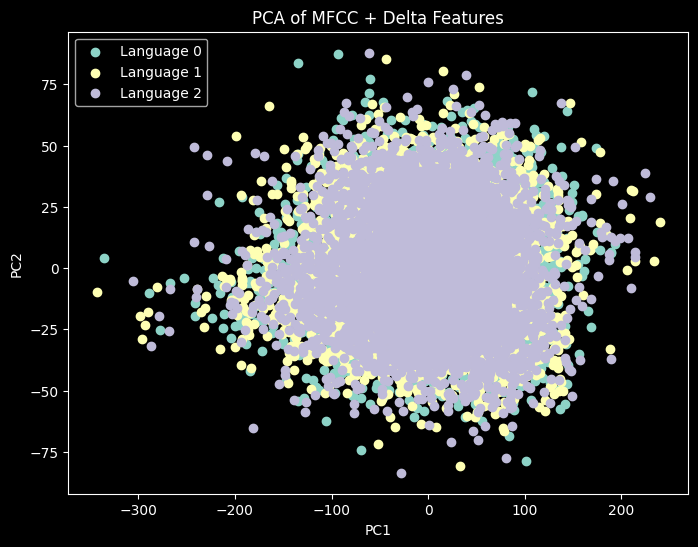

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
plt.style.use('dark_background')
# X: your feature matrix, y: labels (0,1,2 for languages)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)  # shape: (n_samples, 2)

# plot
plt.figure(figsize=(8,6))
for lang in np.unique(y):
    plt.scatter(X_pca[y==lang, 0], X_pca[y==lang, 1], label=f'Language {lang}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of MFCC + Delta Features')
plt.legend()
plt.show()


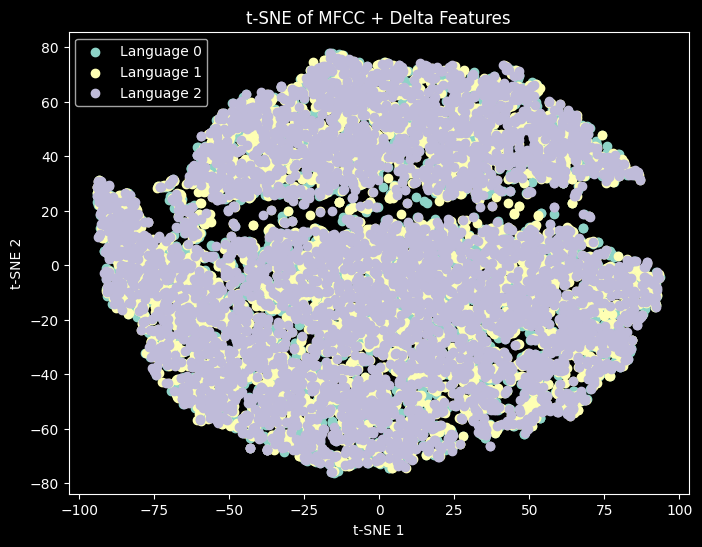

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(x)

plt.figure(figsize=(8,6))
for lang in np.unique(y):
    plt.scatter(X_tsne[y==lang, 0], X_tsne[y==lang, 1], label=f'Language {lang}')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of MFCC + Delta Features')
plt.legend()
plt.show()


# Transformers:

In [ ]:
pd.read_csv('/content/drive/MyDrive/voxpopuli_with_mfcc.csv')

In [ ]:
# --------------------------
# Step 1: Load CSV and encode labels
# --------------------------
df = pd.read_csv('/content/drive/MyDrive/voxpopuli_with_mfcc.csv')  # replace with your CSV path

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['lang'])
num_labels = len(le.classes_)

# Convert label_id to native Python int
df['label_id'] = df['label_id'].astype(int)

# Create label2id and id2label
label2id = {str(k): int(v) for k, v in zip(le.classes_, le.transform(le.classes_))}
id2label = {int(v): str(k) for k, v in zip(le.classes_, le.transform(le.classes_))}

# --------------------------
# Step 2: Train/validation split
# --------------------------
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_id'])

# --------------------------
# Step 3: Audio loading helper
# --------------------------
def load_audio(path, target_sr=16000):
    audio, sr = librosa.load(path, sr=target_sr)  # resamples automatically
    return torch.tensor(audio, dtype=torch.float)  # 1D tensor

# --------------------------
# Step 4: PyTorch Dataset
# --------------------------
class AudioDataset(Dataset):
    def __init__(self, df):
        self.paths = df['audio_path'].tolist()
        self.labels = df['label_id'].tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        audio = load_audio(self.paths[idx])
        label = self.labels[idx]
        return {"audio": audio, "label": torch.tensor(label, dtype=torch.long)}

# --------------------------
# Step 5: Collate function (returns list of 1D Python lists)
# --------------------------
def collate_fn(batch):
    # Convert tensors to Python lists for variable-length audio
    audios = [item['audio'].tolist() for item in batch]
    labels = torch.stack([item['label'] for item in batch])
    return {"input_values": audios, "labels": labels}

# --------------------------
# Step 6: Feature extractor
# --------------------------
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")

# --------------------------
# Step 7: DataLoaders
# --------------------------
train_dataset = AudioDataset(train_df)
val_dataset = AudioDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

# --------------------------
# Step 8: Load Wav2Vec2 model
# --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label
)
model.to(device)

# Optional: enable gradient checkpointing for large models
# model.gradient_checkpointing_enable()

# --------------------------
# Step 9: Optimizer
# --------------------------
optimizer = AdamW(model.parameters(), lr=1e-5)

# --------------------------
# Step 10: Training loop
# --------------------------
epochs = 3  # increase for better performance
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch_input = feature_extractor(
            batch["input_values"],  # list of lists
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        ).input_values.to(device)

        labels = batch["labels"].to(device)

        outputs = model(input_values=batch_input, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

# --------------------------
# Step 11: Evaluation & save probabilities
# --------------------------
model.eval()
all_probs = []
all_labels = []
all_audio_paths = []

with torch.no_grad():
    for batch_idx, batch in enumerate(val_loader):
        batch_input = feature_extractor(
            batch["input_values"],
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        ).input_values.to(device)

        labels = batch["labels"].to(device)
        logits = model(batch_input).logits
        probs = torch.softmax(logits, dim=-1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        batch_start = batch_idx * val_loader.batch_size
        batch_end = batch_start + len(batch["labels"])
        all_audio_paths.extend(val_df['audio_path'].iloc[batch_start:batch_end].tolist())

all_probs = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)

# --------------------------
# Save probabilities to CSV
# --------------------------
prob_df = pd.DataFrame(all_probs, columns=[id2label[i] for i in range(num_labels)])
prob_df.insert(0, "audio_path", all_audio_paths)
prob_df.insert(1, "true_label", [id2label[i] for i in all_labels])

prob_df.to_csv("language_probabilities.csv", index=False)
print("Saved probabilities to language_probabilities.csv")


/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
chunk_size = 100  # number of audios per chunk
num_chunks = int(np.ceil(len(val_df)/chunk_size))


NameError: name 'np' is not defined

In [ ]:
all_probs = []
all_labels = []
all_audio_paths = []

for chunk_idx in range(num_chunks):
    chunk_df = val_df.iloc[chunk_idx*chunk_size : (chunk_idx+1)*chunk_size]

    # Dataset and DataLoader for this chunk
    val_dataset = AudioDataset(chunk_df)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            batch_input = feature_extractor(
                batch["input_values"],
                sampling_rate=16000,
                return_tensors="pt",
                padding=True
            ).input_values.to(device)

            labels = batch["labels"].to(device)
            logits = model(batch_input).logits
            probs = torch.softmax(logits, dim=-1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_audio_paths.extend(chunk_df['audio_path'].iloc[batch_idx*val_loader.batch_size:
                                                               batch_idx*val_loader.batch_size + len(batch["labels"])].tolist())

    # Save intermediate chunk
    if (chunk_idx+1) % 1 == 0:  # save after each chunk
        tmp_probs = np.vstack(all_probs)
        tmp_labels = np.concatenate(all_labels)
        tmp_df = pd.DataFrame(tmp_probs, columns=[id2label[i] for i in range(num_labels)])
        tmp_df.insert(0, "audio_path", all_audio_paths)
        tmp_df.insert(1, "true_label", [id2label[i] for i in tmp_labels])
        tmp_df.to_csv(f"language_probabilities_chunk_{chunk_idx+1}.csv", index=False)
        print(f"Saved chunk {chunk_idx+1}/{num_chunks}")


In [ ]:
def load_audio(path, target_sr=8000):  # reduce input length by 2x
    audio, sr = librosa.load(path, sr=target_sr)
    return torch.tensor(audio, dtype=torch.float)
